# data_loader
Étude de préparation de données : connexion, fusion, et agrégation des ventes journalières.


In [9]:
import pandas as pd
import psycopg2

DB_CONFIG = {
    "dbname": "grocery_db",
    "user": "postgres",
    "password": "2002",
    "host": "localhost",
    "port": 5432,
}


def get_connection():
    return psycopg2.connect(**DB_CONFIG)


## 2. Fusion des tables `fact_sales` et `dim_product`
Une fonction dédiée charge les deux tables et les fusionne sur `productid`.


In [10]:
def load_fact_product_tables():
    """Charge fact_sales et dim_product puis les fusionne par productid."""
    with get_connection() as conn:
        fact = pd.read_sql(
            "SELECT date, productid, customerid, quantity, discount FROM fact_sales",
            conn,
            parse_dates=["date"],
        )
        product = pd.read_sql(
            "SELECT productid, price FROM dim_product",
            conn,
        )

    fact["date"] = pd.to_datetime(fact["date"])
    merged = fact.merge(product, on="productid", how="left")

    if merged["price"].isna().any():
        missing = merged.loc[merged["price"].isna(), "productid"].unique()
        raise ValueError(
            f"Produit(s) manquant(s) dans dim_product pour productid(s)={missing.tolist()}"
        )

    return merged


## 3. Construction d'un index journalier propre
Cette fonction garantit une fréquence quotidienne et comble les jours manquants avec des valeurs médianes.


In [11]:
def ensure_daily_index(df, date_col="date"):
    df = df.set_index(date_col).asfreq("D")
    for col in df.columns:
        df[col] = df[col].fillna(df[col].median())
    return df


## 4. Chargement du revenue journalier consolidé
Fonction de chargement principal qui calcule le revenu et agrège par date.


In [12]:
def load_daily_revenue():
    """Charge le revenue journalier consolidé depuis les tables de ventes."""
    merged = load_fact_product_tables()
    merged["revenue"] = merged["price"] * merged["quantity"] - merged["discount"]

    daily = merged.groupby("date", as_index=False)["revenue"].sum()
    daily = ensure_daily_index(daily)
    daily["revenue"] = daily["revenue"].astype(float)

    return daily


## 5. Chargement des données enrichies pour le ML
Cette fonction construit des indicateurs journaliers supplémentaires utiles pour le niveau 2.


In [13]:
def load_daily_enriched_data():
    """Charge les métriques journalières enrichies pour le ML classique."""
    merged = load_fact_product_tables()
    merged["revenue"] = merged["price"] * merged["quantity"] - merged["discount"]

    daily = merged.groupby("date", as_index=False).agg(
        revenue=("revenue", "sum"),
        nb_transactions=("productid", "count"),
        total_qty=("quantity", "sum"),
        avg_discount=("discount", "mean"),
        nb_customers=("customerid", "nunique"),
        nb_products=("productid", "nunique"),
    )

    daily = ensure_daily_index(daily)
    daily = daily.astype({
        "revenue": float,
        "nb_transactions": float,
        "total_qty": float,
        "avg_discount": float,
        "nb_customers": float,
        "nb_products": float,
    })

    return daily


## 6. Agrégation mensuelle
Prépare un dataset mensuel pour l'entraînement sur 2018-2022 et la prévision de 2023.


In [14]:
def load_monthly_enriched_data():
    """Charge les métriques agrégées par mois pour le ML de forecasting."""
    merged = load_fact_product_tables()
    merged["revenue"] = merged["price"] * merged["quantity"] - merged["discount"]

    monthly = merged.groupby(pd.Grouper(key="date", freq="MS")).agg(
        revenue=("revenue", "sum"),
        nb_transactions=("productid", "count"),
        total_qty=("quantity", "sum"),
        avg_discount=("discount", "mean"),
        nb_customers=("customerid", "nunique"),
        nb_products=("productid", "nunique"),
    )

    monthly = monthly.asfreq("MS")
    for col in ["revenue", "nb_transactions", "total_qty", "avg_discount", "nb_customers", "nb_products"]:
        monthly[col] = monthly[col].fillna(monthly[col].median())

    monthly = monthly.astype({
        "revenue": float,
        "nb_transactions": float,
        "total_qty": float,
        "avg_discount": float,
        "nb_customers": float,
        "nb_products": float,
    })

    return monthly

# Exemple d'utilisation pour la période 2018-2022
monthly = load_monthly_enriched_data()
print("=== Monthly data ===")
print(monthly.head())
print("\n=== Range & train period ===")
train = monthly.loc["2018-01-01":"2022-12-31"]
print(train.index.min(), train.index.max(), "| rows:", len(train))

# Prévision 2023 : horizon mensuel
future_index = pd.date_range(start="2023-01-01", end="2023-12-01", freq="MS")
print("Prévision possible pour 2023 :", len(future_index), "mois")


C:\Users\lenovo\AppData\Local\Temp\ipykernel_18736\2698247858.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  fact = pd.read_sql(
C:\Users\lenovo\AppData\Local\Temp\ipykernel_18736\2698247858.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  product = pd.read_sql(


=== Monthly data ===
               revenue  nb_transactions  total_qty  avg_discount  \
date                                                               
2018-01-01  44040714.7          66809.0   868664.0      0.030165   
2018-02-01  38573083.6          58505.0   757640.0      0.030018   
2018-03-01  49744294.6          75578.0   981262.0      0.029929   
2018-04-01  49456018.5          74875.0   974111.0      0.030592   
2018-05-01  55958284.7          84196.0  1100294.0      0.029582   

            nb_customers  nb_products  
date                                   
2018-01-01       48637.0        452.0  
2018-02-01       44164.0        452.0  
2018-03-01       52884.0        452.0  
2018-04-01       52444.0        452.0  
2018-05-01       56514.0        452.0  

=== Range & train period ===
2018-01-01 00:00:00 2022-12-01 00:00:00 | rows: 60
Prévision possible pour 2023 : 12 mois


## 6. Aperçu des données
Affichage des premières lignes des jeux de données chargés.

In [15]:
# Aperçu rapide des jeux de données
print("=== daily revenue ===")
daily = load_daily_revenue()
print(daily.head())

print("\n=== enriched daily data ===")
enriched = load_daily_enriched_data()
print(enriched.head())

=== daily revenue ===


C:\Users\lenovo\AppData\Local\Temp\ipykernel_18736\2698247858.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  fact = pd.read_sql(
C:\Users\lenovo\AppData\Local\Temp\ipykernel_18736\2698247858.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  product = pd.read_sql(


              revenue
date                 
2018-01-01  1341735.4
2018-01-02  1411294.8
2018-01-03  1377772.5
2018-01-04  1436680.8
2018-01-05  1374454.5

=== enriched daily data ===


C:\Users\lenovo\AppData\Local\Temp\ipykernel_18736\2698247858.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  fact = pd.read_sql(
C:\Users\lenovo\AppData\Local\Temp\ipykernel_18736\2698247858.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  product = pd.read_sql(


              revenue  nb_transactions  total_qty  avg_discount  nb_customers  \
date                                                                            
2018-01-01  1341735.4           2071.0    27152.0      0.030806        2049.0   
2018-01-02  1411294.8           2163.0    28228.0      0.028803        2138.0   
2018-01-03  1377772.5           2088.0    27368.0      0.029837        2069.0   
2018-01-04  1436680.8           2155.0    27771.0      0.030719        2129.0   
2018-01-05  1374454.5           2118.0    27614.0      0.029698        2093.0   

            nb_products  
date                     
2018-01-01        447.0  
2018-01-02        446.0  
2018-01-03        447.0  
2018-01-04        447.0  
2018-01-05        448.0  


## 7. Visualisation du revenu journalier
Tracer une courbe de l'évolution du revenu en fonction de la date.


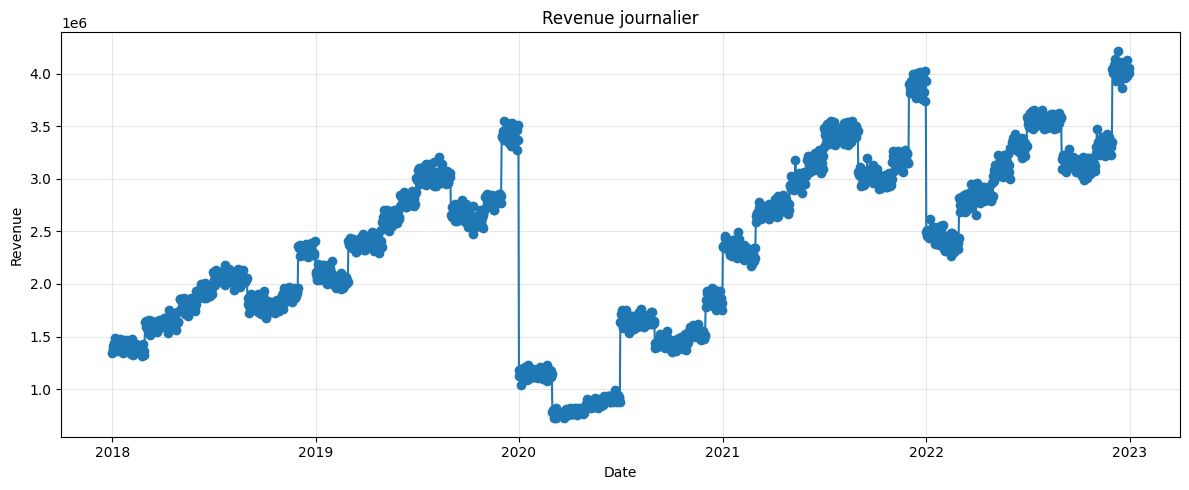

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(daily.index, daily["revenue"], marker="o", linestyle="-", color="#1f77b4")
plt.title("Revenue journalier")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
